---
title: Money Laundering Detection with Multi-Aggregation Custom Edge GIN - Supplementary Material
format: pdf
pdf:
    fig-pos: 'H'
bibliography: supplement.bib
execute:
    echo: false
---

::: {.content-hidden}
# Library imports

This notebook can be run using the Quarto tool to generate PDF supplementary material for the paper.

:::

In [138]:
import autoroot #noqa
import autorootcwd #noqa

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=ValueWarning)

from pathlib import Path

import joblib
import pandas as pd
import torch as th
import torch_geometric as pyg
import matplotlib.pyplot as plt
from IPython.display import Markdown, display_markdown

import aml_magic.src.consts as cc
import aml_magic.src.models.magic as magic
import aml_magic.src.stages.hp_tune as hp_tune
import aml_magic.src.utils.configs as cfg
import aml_magic.src.utils.results_summary_utils as analysis

In [139]:
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

::: {.content-hidden}
# Data loading
:::

In [140]:
human_friendly_datasets = {
    "AMLSim 1/3": "amlsim_31",
    "AMLSim 1/5": "amlsim_51",
    "AMLSim 1/10": "amlsim_101",
    "AMLSim 1/20": "amlsim_201"
}

optuna_studies = {
    "AMLSim 1/3": analysis.load_study("amlsim_31"),
    "AMLSim 1/5": analysis.load_study("amlsim_51"),
    "AMLSim 1/10": analysis.load_study("amlsim_101"),
    "AMLSim 1/20": analysis.load_study("amlsim_201")
}

ds_to_human_friendly = {v: k for k, v in human_friendly_datasets.items()}

dataset_configs = {}
dataset_data = {}

for ds in human_friendly_datasets.values():
    configs = hp_tune.prepare_configs(ds)
    dataset_configs[ds] = configs

    ds_path = Path(configs.data_configs.output_path, configs.dsname)
    train_val_data_container_for_ds = hp_tune.prepare_data_for_dataset(configs)
    train_graphs = train_val_data_container_for_ds.train_dataset
    val_graphs = train_val_data_container_for_ds.val_dataset
    # A trick - using the DataLoader to get the combined train and val graphs (originally theu are split into chunks)
    train_graphs_combined = pyg.data.Batch.from_data_list(train_graphs)
    val_graphs_combined = pyg.data.Batch.from_data_list(val_graphs)

    test_data = joblib.load(ds_path / "test_graphs.pkl")
    test_graphs_combined = pyg.data.Batch.from_data_list(test_data)

    dataset_data[ds] = {"train": train_graphs_combined, "val": val_graphs_combined, "test": test_graphs_combined}

# The data

This study builds upon the datasets and methodological framework established by [@Silva2023]. Their research utilized data generated by the financial transaction simulation tool "AMLSim", developed by IBM [@Weber2018]. AMLSim extends the capabilities of the PaySim architecture and was designed to simulate transactional patterns characteristic of money laundering processes. This simulator stands out for its ability to fine-tune a wide range of parameters, such as the duration of the simulation in time steps (days), transaction value ranges, and class imbalance ratio, among other statistical variables.

In their study, @Silva2023 generated a dataset representing daily transaction activities for the year 2020, encompassing a total of 365 time steps. This dataset includes account identifiers, predetermined suspicion indicators, details on the sending and receiving accounts, and transaction types. The main elements for their analysis included the transaction value (*"base_amt"*}), transaction timestamp (*"tran_timestamp"*), and transaction type (*"tx_type"*), along with flags indicating potential illicit activities (*"is_sar"*), and data on the source or destination accounts (*"orig_acct"*, *"bene_acct"*). These elements were used to construct the transaction graphs, supplemented by initial deposit information (*"initial_deposit"*) and transaction behaviour categorizations (*"tx_behavior_id"*) for each account. That dataset was divided into several portions with different class imbalance rates.

[@tbl-datasets] summarizes the key elements of the datasets used in this study - number of nodes and edges in train/validation/test splits. [@tbl-class-proportions] presents the class proportions for the different datasets.

In [141]:
#| label: tbl-datasets
#| tbl-cap: "Dataset statistics"

data_stats = []
class_proportions = []

for ds, data in dataset_data.items():
    ds_friendly_name = ds_to_human_friendly[ds]
    num_nodes_train = data["train"].num_nodes
    num_nodes_val = data["val"].num_nodes
    num_nodes_test = data["test"].num_nodes
    num_edges_train = data["train"].num_edges
    num_edges_val = data["val"].num_edges
    num_edges_test = data["test"].num_edges

    class_props = pd.value_counts(data['train'].y)
    class_props_perc = class_props / class_props.sum()

    class_proportions.append((ds_friendly_name, class_props[0], class_props_perc[0], class_props[1], class_props_perc[1]))
    data_stats.append([ds_friendly_name, num_nodes_train, num_nodes_val, num_nodes_test, num_edges_train, num_edges_val, num_edges_test])

df_dataset_stats = pd.DataFrame(data_stats, columns=["Dataset", "# train nodes", "# val nodes", "# test nodes", "# train edges", "# val edges", "# test edges"])
df_class_stats = pd.DataFrame(class_proportions, columns=["Dataset", "# legal", "% legal", "# illicit", "% illicit"])

Markdown(df_dataset_stats.to_markdown(index=False))

| Dataset     |   # train nodes |   # val nodes |   # test nodes |   # train edges |   # val edges |   # test edges |
|:------------|----------------:|--------------:|---------------:|----------------:|--------------:|---------------:|
| AMLSim 1/3  |            3889 |          1186 |           1256 |            1977 |           599 |            637 |
| AMLSim 1/5  |            6338 |          2036 |           2133 |            3226 |          1039 |           1090 |
| AMLSim 1/10 |           12330 |          4239 |           4182 |            6366 |          2184 |           2160 |
| AMLSim 1/20 |           24283 |          7945 |           8036 |           12931 |          4222 |           4267 |

In [142]:
#| label: tbl-class-proportions
#| tbl-cap: "Class proportions per dataset"
Markdown(df_class_stats.round(3).to_markdown(index=False))

| Dataset     |   # legal |   % legal |   # illicit |   % illicit |
|:------------|----------:|----------:|------------:|------------:|
| AMLSim 1/3  |      1317 |     0.666 |         660 |       0.334 |
| AMLSim 1/5  |      2566 |     0.795 |         660 |       0.205 |
| AMLSim 1/10 |      5706 |     0.896 |         660 |       0.104 |
| AMLSim 1/20 |     12271 |     0.949 |         660 |       0.051 |

# Hyperparameter optimization

While a traditional ablation study was not conducted, the contribution of each hyperparameter to model performance was systematically evaluated using the PED-ANOVA Importance. This method serves as a possible alternative to ablation studies, particularly in cases where the number of tuned parameters is large and their interactions form subspaces (e.g., the interplay between the number of layers, layer size, and aggregation methods per layer). By leveraging ANOVA-based calculations, PED-ANOVA quantifies how strongly each hyperparameter contributes to achieving performance above a baseline, which is determined by fitting Parzen estimators to the results of completed trials [@watanabe2023ped].

The feature importance analysis revealed that no single hyperparameter dominated performance across all datasets. Instead, the relative importance varied depending on dataset properties, particularly the class imbalance ratio and dataset size. For less-imbalanced cases (AMLSim 1/3 and 1/5), the number and size of convolutional layers, as well as aggregation functions, were relatively more influential, though their importance scores were comparable. In contrast, in highly imbalanced scenarios (AMLSim 1/10 and 1/20), embedding reduction modes became more critical, alongside aggregation functions.

This variability highlights the importance of adaptive hyperparameter tuning tailored to dataset-specific properties. The flexibility of the MAGIC architecture further supports effective performance under a wide range of configurations, including the use of multiple, learnable aggregations.

Sections below present details on subsequent aspects of the hyperparameter optimization results - jointly and individually for each dataset.

## Hyperparameter importances

[@fig-hp-importances] illustrates the relative importance of each hyperparameter across the different datasets. The importance scores were calculated using the PED-ANOVA method, which quantifies the contribution of each hyperparameter to the model's performance above a baseline. The baseline was determined by fitting Parzen estimators to the results of completed trials.

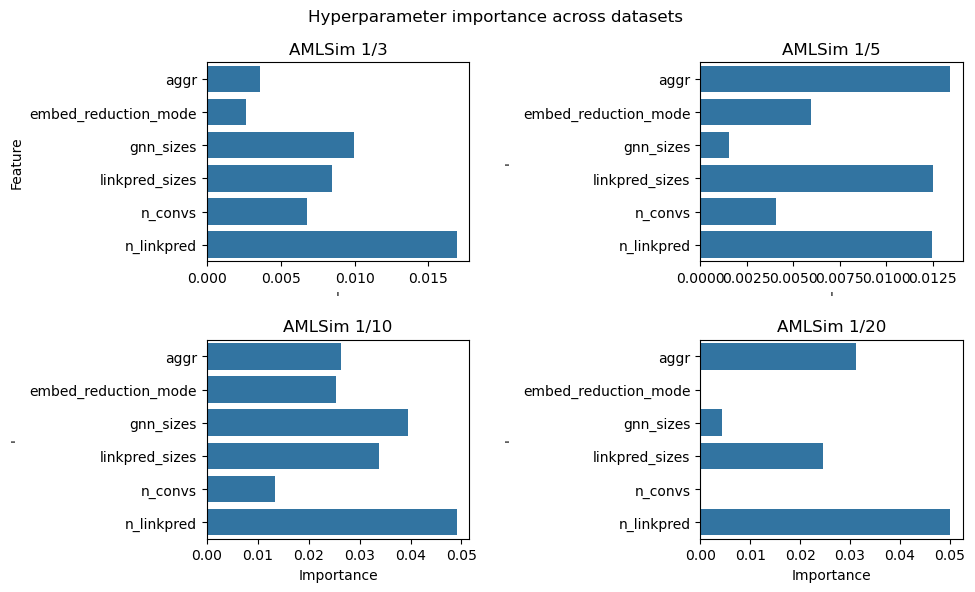

In [143]:
#| label: fig-hp-importances
#| fig-cap: PED-ANOVA hyperparameter importances across datasets.


analysis.plot_importance_barplot(optuna_studies)

Subsequent tables [@tbl-amlsim13-anova], [@tbl-amlsim15-anova], [@tbl-amlsim101-anova], and [@tbl-amlsim201-anova] present the detailed results of the PED-ANOVA analysis for each dataset. The tables include the hyperparameter name, the importance F-score, and the corresponding p-value.

In [144]:
#| label: tbl-amlsim13-anova
#| tbl-cap: Anova results for AMLSim 1/3.

anova_res = analysis.anova_check_importance(optuna_studies["AMLSim 1/3"])
anova_res_md = Markdown(anova_res.round(4).to_markdown(index=False))
display_markdown(anova_res_md)

| Source                                                  |      SS |   DF |      MS |        F |   p-unc |      np2 | Significance   |
|:--------------------------------------------------------|--------:|-----:|--------:|---------:|--------:|---------:|:---------------|
| Conv. Dim.                                              |  0      |    3 |  0      |     0    |       1 |   0      | No             |
| No. Conv. Layers                                        | -0      |    2 | -0      |    -0    |       1 |  -0      | No             |
| Aggr.                                                   | -0      |    4 | -0      |    -0    |       1 |  -0      | No             |
| Embed Reduction                                         |  0.0555 |    1 |  0.0555 |  3629.56 |       0 |   0.9959 | Yes            |
| Conv. Dim. * No. Conv. Layers                           |  0      |    6 |  0      |     0    |       1 |   0      | No             |
| Conv. Dim. * Aggr.                                      | 14.0643 |   12 |  1.172  | 76630.3  |       0 |   1      | Yes            |
| No. Conv. Layers * Aggr.                                | -0      |    8 | -0      |    -0    |       1 |  -0      | No             |
| Conv. Dim. * Embed Reduction                            |  0      |    3 |  0      |     0    |       1 |   0      | No             |
| No. Conv. Layers * Embed Reduction                      |  0.1503 |    2 |  0.0752 |  4914.07 |       0 |   0.9985 | Yes            |
| Aggr. * Embed Reduction                                 | -0      |    4 | -0      |    -0    |       1 |  -0      | No             |
| Conv. Dim. * No. Conv. Layers * Aggr.                   | 20.9588 |   24 |  0.8733 | 57097.9  |       0 |   1      | Yes            |
| Conv. Dim. * No. Conv. Layers * Embed Reduction         |  0.1418 |    6 |  0.0236 |  1544.69 |       0 |   0.9984 | Yes            |
| Conv. Dim. * Aggr. * Embed Reduction                    |  5.7815 |   12 |  0.4818 | 31500.9  |       0 |   1      | Yes            |
| No. Conv. Layers * Aggr. * Embed Reduction              |  0.7407 |    8 |  0.0926 |  6053.83 |       0 |   0.9997 | Yes            |
| Conv. Dim. * No. Conv. Layers * Aggr. * Embed Reduction |  6.6888 |   24 |  0.2787 | 18222.3  |       0 |   1      | Yes            |
| Residual                                                |  0.0002 |   15 |  0      |   nan    |     nan | nan      | No             |

In [145]:
#| label: tbl-amlsim15-anova
#| tbl-cap: Anova results for AMLSim 1/5.

anova_res = analysis.anova_check_importance(optuna_studies["AMLSim 1/5"])
anova_res_md = Markdown(anova_res.round(4).to_markdown(index=False))
display_markdown(anova_res_md)

| Source                                                  |      SS |   DF |      MS |        F |    p-unc |      np2 | Significance   |
|:--------------------------------------------------------|--------:|-----:|--------:|---------:|---------:|---------:|:---------------|
| Conv. Dim.                                              | -0      |    3 | -0      |  -0      |   1      |  -0      | No             |
| No. Conv. Layers                                        | -0      |    2 | -0      |  -0      |   1      |  -0      | No             |
| Aggr.                                                   |  0      |    4 |  0      |   0      |   1      |   0      | No             |
| Embed Reduction                                         |  0      |    1 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * No. Conv. Layers                           |  0      |    6 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * Aggr.                                      |  0      |   12 |  0      |   0      |   1      |   0      | No             |
| No. Conv. Layers * Aggr.                                |  0      |    8 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * Embed Reduction                            |  0      |    3 |  0      |   0      |   1      |   0      | No             |
| No. Conv. Layers * Embed Reduction                      | -0      |    2 | -0      |  -0      |   1      |  -0      | No             |
| Aggr. * Embed Reduction                                 |  0      |    4 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * No. Conv. Layers * Aggr.                   | 24.1042 |   24 |  1.0043 |  94.3579 |   0      |   0.9934 | Yes            |
| Conv. Dim. * No. Conv. Layers * Embed Reduction         |  4.4824 |    6 |  0.7471 |  70.1874 |   0      |   0.9656 | Yes            |
| Conv. Dim. * Aggr. * Embed Reduction                    |  7.5262 |   12 |  0.6272 |  58.9242 |   0      |   0.9792 | Yes            |
| No. Conv. Layers * Aggr. * Embed Reduction              |  1.6184 |    8 |  0.2023 |  19.0058 |   0.0001 |   0.9102 | Yes            |
| Conv. Dim. * No. Conv. Layers * Aggr. * Embed Reduction |  4.029  |   24 |  0.1679 |  15.7718 |   0      |   0.9619 | Yes            |
| Residual                                                |  0.1597 |   15 |  0.0106 | nan      | nan      | nan      | No             |

In [146]:
#| label: tbl-amlsim101-anova
#| tbl-cap: Anova results for AMLSim 1/10.

anova_res = analysis.anova_check_importance(optuna_studies["AMLSim 1/10"])
anova_res_md = Markdown(anova_res.round(4).to_markdown(index=False))
display_markdown(anova_res_md)

| Source                                                  |      SS |   DF |      MS |        F |    p-unc |      np2 | Significance   |
|:--------------------------------------------------------|--------:|-----:|--------:|---------:|---------:|---------:|:---------------|
| Conv. Dim.                                              |  0.0868 |    3 |  0.0289 |   0.9192 |   0.4504 |   0.1267 | No             |
| No. Conv. Layers                                        |  0      |    2 |  0      |   0      |   1      |   0      | No             |
| Aggr.                                                   |  0.0886 |    4 |  0.0222 |   0.7037 |   0.5991 |   0.129  | No             |
| Embed Reduction                                         | -0.0101 |    1 | -0.0101 |  -0.3214 |   1      |  -0.0172 | No             |
| Conv. Dim. * No. Conv. Layers                           |  0      |    6 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * Aggr.                                      |  0      |   12 |  0      |   0      |   1      |   0      | No             |
| No. Conv. Layers * Aggr.                                |  0      |    8 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * Embed Reduction                            | -0.0035 |    3 | -0.0012 |  -0.0367 |   1      |  -0.0058 | No             |
| No. Conv. Layers * Embed Reduction                      | -0      |    2 | -0      |  -0      |   1      |  -0      | No             |
| Aggr. * Embed Reduction                                 |  0      |    4 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * No. Conv. Layers * Aggr.                   | 17.479  |   24 |  0.7283 |  23.1337 |   0      |   0.9669 | Yes            |
| Conv. Dim. * No. Conv. Layers * Embed Reduction         |  0.5281 |    6 |  0.088  |   2.7957 |   0.0682 |   0.4689 | No             |
| Conv. Dim. * Aggr. * Embed Reduction                    |  1.4988 |   12 |  0.1249 |   3.9674 |   0.0237 |   0.7148 | Yes            |
| No. Conv. Layers * Aggr. * Embed Reduction              |  0.0882 |    8 |  0.011  |   0.3502 |   0.901  |   0.1285 | No             |
| Conv. Dim. * No. Conv. Layers * Aggr. * Embed Reduction |  4.919  |   24 |  0.205  |   6.5104 |   0.0001 |   0.8916 | Yes            |
| Residual                                                |  0.5982 |   19 |  0.0315 | nan      | nan      | nan      | No             |

In [147]:
#| label: tbl-amlsim201-anova
#| tbl-cap: Anova results for AMLSim 1/20.

anova_res = analysis.anova_check_importance(optuna_studies["AMLSim 1/20"])
anova_res_md = Markdown(anova_res.round(4).to_markdown(index=False))
display_markdown(anova_res_md)

| Source                                                  |      SS |   DF |      MS |        F |    p-unc |      np2 | Significance   |
|:--------------------------------------------------------|--------:|-----:|--------:|---------:|---------:|---------:|:---------------|
| Conv. Dim.                                              | -0      |    3 | -0      |  -0      |   1      |  -0      | No             |
| No. Conv. Layers                                        |  0.0072 |    2 |  0.0036 |   1.2612 |   0.31   |   0.1362 | No             |
| Aggr.                                                   |  0      |    4 |  0      |   0      |   1      |   0      | No             |
| Embed Reduction                                         |  0.0028 |    1 |  0.0028 |   0.9897 |   0.3346 |   0.0583 | No             |
| Conv. Dim. * No. Conv. Layers                           |  0      |    6 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * Aggr.                                      | -0      |   12 | -0      |  -0      |   1      |  -0      | No             |
| No. Conv. Layers * Aggr.                                |  0      |    8 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * Embed Reduction                            | -0      |    3 | -0      |  -0      |   1      |  -0      | No             |
| No. Conv. Layers * Embed Reduction                      |  0      |    2 |  0      |   0      |   1      |   0      | No             |
| Aggr. * Embed Reduction                                 |  0      |    4 |  0      |   0      |   1      |   0      | No             |
| Conv. Dim. * No. Conv. Layers * Aggr.                   | 14.7529 |   24 |  0.6147 | 215.651  |   0      |   0.9969 | Yes            |
| Conv. Dim. * No. Conv. Layers * Embed Reduction         |  0.7525 |    6 |  0.1254 |  43.9988 |   0      |   0.9429 | Yes            |
| Conv. Dim. * Aggr. * Embed Reduction                    |  1.579  |   12 |  0.1316 |  46.162  |   0      |   0.9719 | Yes            |
| No. Conv. Layers * Aggr. * Embed Reduction              |  3.7461 |    8 |  0.4683 | 164.276  |   0      |   0.988  | Yes            |
| Conv. Dim. * No. Conv. Layers * Aggr. * Embed Reduction |  3.9741 |   24 |  0.1656 |  58.0913 |   0      |   0.9887 | Yes            |
| Residual                                                |  0.0456 |   16 |  0.0029 | nan      | nan      | nan      | No             |

## Complexity and quality

The tuning process revealed a consistent trade-off between model complexity and illicit F1 scores. Simpler models, characterized by fewer layers and smaller convolutional dimensions, matched or outperformed more complex variants every time. Figure [@fig-f1-vs-complexity] illustrates the relationship between model complexity and illicit F1 scores across all datasets. As a result, simpler architectures were selected whenever performance differences were negligible.

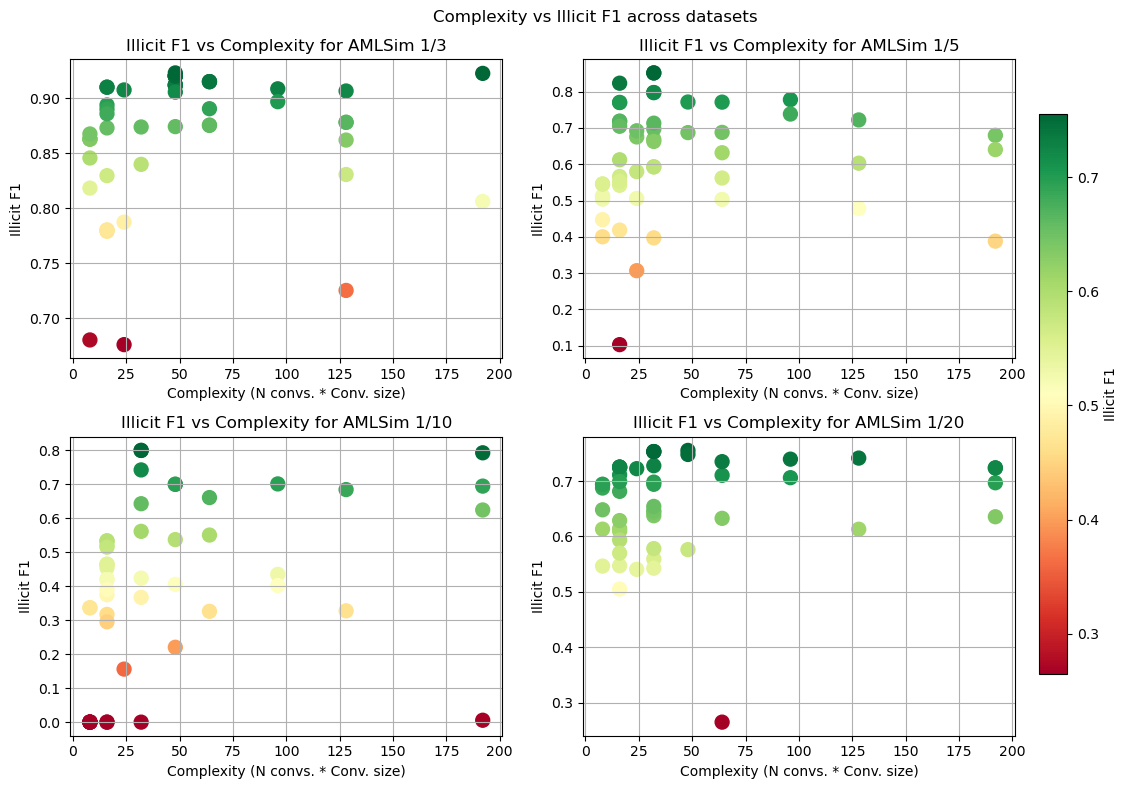

In [148]:
#| label: fig-f1-vs-complexity
#| fig-cap: F1 score vs complexity across datasets.
analysis.make_f1_vs_complexity_joint_plot(optuna_studies, save=False, figsize=(12, 8));

[@fig-gnn-sizes-vs-n-convs] presents only the interaction between complexity (number of layers and their size) and illicit F1 scores. For every dataset simpler models exihibit similar or better performance than more complex ones.

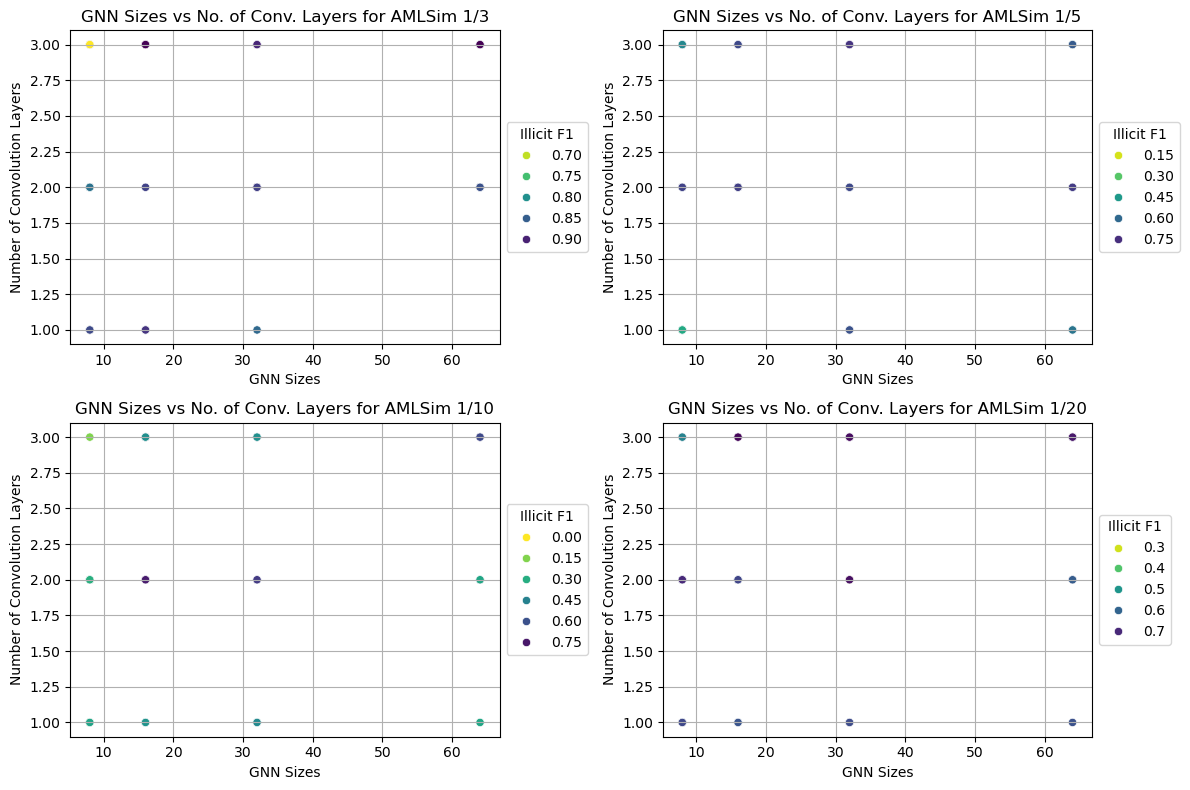

In [149]:
#| label: fig-gnn-sizes-vs-n-convs
#| fig-cap: GNN sizes vs number of convolutions across datasets.
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for i, (ds, study) in enumerate(optuna_studies.items()):
    analysis.plot_gnn_sizes_vs_n_convs(study=study, dataset_name=ds, ax=ax[i], fig=fig, save=False, show=False)
plt.tight_layout()
fig;

# Model structure

This section presents the details of the final convolution layers selected for each dataset. Tables [@tbl-model-summary-amlsim13], [@tbl-model-summary-amlsim15], [@tbl-model-summary-amlsim101], and [@tbl-model-summary-amlsim201] summarize the final model configurations for the AMLSim 1/3, 1/5, 1/10, and 1/20 datasets, respectively.

In [150]:
model_summaries = {}
archs = {}
for dataset, config in dataset_configs.items():
    base_arch = config.training_configs.get_achitecture_for_dataset(config.dsname)
    archs[dataset] = base_arch
    train_data = dataset_data[dataset]["train"]
    model = magic.MAGICPl(**base_arch.model_dump()).magic_linkpred.magic

    model_summary = pyg.nn.summary(model, train_data.x, train_data.edge_index, train_data.edge_attr)
    model_summary_md = Markdown(analysis.clean_torch_model_summary(model_summary))
    model_summaries[dataset] = model_summary_md

In [151]:
#| label: tbl-model-summary-amlsim13
#| tbl-cap: Model summary for AMLSim 1/3.

display_markdown(model_summaries["amlsim_31"])

| Layer               | Input Shape                     | Output Shape   |   #Param |
|---------------------|---------------------------------|----------------|----------|
| MAGICModel          | [3889, 6], [2, 1977], [1977, 8] | [3889, 8]      |      480 |
| ├─(convs)ModuleList | --                              | --             |      480 |
| │    └─(0)MAGICConv | [3889, 6], [2, 1977], [1977, 8] | [3889, 8]      |      207 |
| │    └─(1)MAGICConv | [3889, 8], [2, 1977], [1977, 8] | [3889, 8]      |      273 |

In [152]:
#| label: tbl-model-summary-amlsim15
#| tbl-cap: Model summary for AMLSim 1/5.
display_markdown(model_summaries["amlsim_51"])

| Layer               | Input Shape                      | Output Shape   | #Param   |
|---------------------|----------------------------------|----------------|----------|
| MAGICModel          | [6338, 6], [2, 3226], [3226, 8]  | [6338, 16]     | 1,288    |
| ├─(convs)ModuleList | --                               | --             | 1,288    |
| │    └─(0)MAGICConv | [6338, 6], [2, 3226], [3226, 8]  | [6338, 16]     | 359      |
| │    └─(1)MAGICConv | [6338, 16], [2, 3226], [3226, 8] | [6338, 16]     | 929      |

In [153]:
#| label: tbl-model-summary-amlsim101
#| tbl-cap: Model summary for AMLSim 1/10.
display_markdown(model_summaries["amlsim_101"])

| Layer               | Input Shape                       | Output Shape   | #Param   |
|---------------------|-----------------------------------|----------------|----------|
| MAGICModel          | [12330, 6], [2, 6366], [6366, 8]  | [12330, 16]    | 1,640    |
| ├─(convs)ModuleList | --                                | --             | 1,640    |
| │    └─(0)MAGICConv | [12330, 6], [2, 6366], [6366, 8]  | [12330, 16]    | 455      |
| │    └─(1)MAGICConv | [12330, 16], [2, 6366], [6366, 8] | [12330, 16]    | 1,185    |

In [154]:
#| label: tbl-model-summary-amlsim201
#| tbl-cap: Model summary for AMLSim 1/20.
display_markdown(model_summaries["amlsim_201"])

| Layer               | Input Shape                         | Output Shape   | #Param   |
|---------------------|-------------------------------------|----------------|----------|
| MAGICModel          | [24283, 6], [2, 12931], [12931, 8]  | [24283, 16]    | 1,610    |
| ├─(convs)ModuleList | --                                  | --             | 1,610    |
| │    └─(0)MAGICConv | [24283, 6], [2, 12931], [12931, 8]  | [24283, 16]    | 264      |
| │    └─(1)MAGICConv | [24283, 16], [2, 12931], [12931, 8] | [24283, 16]    | 674      |
| │    └─(2)MAGICConv | [24283, 16], [2, 12931], [12931, 8] | [24283, 16]    | 674      |

# References

::: {#refs}
:::